In [1]:
import pandas as pd
from math import exp
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from y_n import y_n_distribution
from upsilon_n import upsilon_n
import multiprocessing
from scipy.optimize import curve_fit
from sklearn.cluster import MeanShift
import random

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
np.random.seed(84)
random.seed(84)

In [4]:
# pd.set_option('display.float_format', '{:,.4E}'.format)

In [5]:
pd.options.display.max_seq_items = 2000

In [6]:
reconciled_data = pd.read_pickle('reconciled_data_validation.pkl')

In [7]:
kinetic_data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

In [8]:
X = kinetic_data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)
clustering.labels_

array([2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 1, 1, 1,
       1, 1, 3, 3, 2, 2, 2, 0, 0, 0, 0, 3, 3, 0, 0, 0, 2, 2, 2, 3, 3, 3,
       2, 2, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

In [9]:
kinetic_data['cluster'] = clustering.labels_

In [10]:
cluster_set = list(set(kinetic_data.cluster))

In [11]:
val_clusters = random.sample(cluster_set, 2)
val_clusters

[5, 2]

In [12]:
kinetic_data.groupby(['cluster'])['T_R_C'].mean().sort_values()

cluster
3    211.000000
0    222.000000
2    233.000000
1    243.687500
5    253.500000
4    262.545455
Name: T_R_C, dtype: float64

In [13]:
kinetic_data.groupby(['cluster'])['T_R_C'].std()

cluster
0    0.000000
1    0.478714
2    0.000000
3    0.000000
4    0.522233
5    0.527046
Name: T_R_C, dtype: float64

In [14]:
kinetic_data['cluster'].isin(val_clusters).sum() / len(kinetic_data)

np.float64(0.3023255813953488)

In [15]:
Fj_out = kinetic_data[[
    'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s',
       'F_CO2_s_mol_s', 'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s',
       'F_H2O_s_mol_s',
    'F_C9', 'F_C10', 'F_C11',
       'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18', 'F_C19',
       'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26', 'F_C27',
       'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34', 'F_C35',
       'F_C36', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14', 'F_Olef_C15',
       'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
]]

Fout = Fj_out.sum(axis=1)
y_H2_out = Fj_out['F_H2_s_mol_s'] / Fout
y_CO_out = Fj_out['F_CO_s_mol_s'] / Fout

In [16]:
F_CO_in = kinetic_data.F_CO_e_mol_s
F_CO_out = kinetic_data.F_CO_s_mol_s
W = kinetic_data.m_cat_g

kinetic_data['-r_CO_exp'] = (F_CO_in - F_CO_out) / W

F_H2_in = kinetic_data.F_H2_e_mol_s
F_H2_out = kinetic_data.F_H2_s_mol_s

kinetic_data['-r_H2_exp'] = (F_H2_in - F_H2_out) / W
kinetic_data['r_H2O_exp'] = kinetic_data['F_H2O_s_mol_s'] / W

In [17]:
n_parafins = {}
for i, parafin in enumerate(parafins):
    n = i + 1
    if n not in [4, 5, 6]:
        n_parafins[parafin] = n

In [18]:
n_olefins = {}
for i, olefin in enumerate(olefins):
    n = i + 2
    if n not in [3, 4, 5, 6]:
        n_olefins[olefin] = n

In [19]:
y_H2_in = F_H2_in / (F_H2_in + F_CO_in)
y_CO_in = F_CO_in / (F_H2_in + F_CO_in)

y_H2_mean = ( y_H2_in + y_H2_out ) / 2
y_CO_mean = ( y_CO_in + y_CO_out ) / 2

kinetic_data['P_H2'] = (kinetic_data.P_abs_Pa * y_H2_out).astype('float')
kinetic_data['P_CO'] = (kinetic_data.P_abs_Pa * y_CO_out).astype('float')

In [20]:
N = [1, 2, 3, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
# N = list(range(1,50))

predicted_y_n = pd.DataFrame()

temperature = kinetic_data.T_R_K
H2_CO = ( F_H2_in / F_CO_in )

predicted_y_n = pd.DataFrame(y_n_distribution(temperature, H2_CO, N))

sum_n_yn = predicted_y_n.mul(predicted_y_n.columns, axis=1).sum(axis=1)

sum_yn_upsilon_n = predicted_y_n.mul(upsilon_n(predicted_y_n.columns), axis=1).sum(axis=1)

sum_yn_upsilon_n_2n = sum_yn_upsilon_n + 2 * sum_n_yn

kinetic_data['sum_n_yn'] = sum_n_yn
kinetic_data['sum_yn_upsilon_n_2n'] = sum_yn_upsilon_n_2n

In [21]:
loc_validation = kinetic_data['cluster'].isin(val_clusters)
loc_training = ~loc_validation
kinetic_data['training'] = loc_training

In [22]:
len(kinetic_data) == len(kinetic_data.loc[loc_validation]) + len(kinetic_data.loc[loc_training])

True

In [23]:
def residuals(params, dataset, rate_fcn):
    r_CO_model = - rate_fcn(*params, dataset.T_R_K, dataset.P_CO, dataset.P_H2) * dataset['sum_n_yn']
    r_CO_exp = - dataset['-r_CO_exp']
    r_H2_model = - rate_fcn(*params, dataset.T_R_K, dataset.P_CO, dataset.P_H2) * dataset['sum_yn_upsilon_n_2n']
    r_H2_exp = - dataset['-r_H2_exp']
    
    res_CO = r_CO_exp - r_CO_model
    res_H2 = r_H2_exp - r_H2_model
    
    F_H2_out_model = r_H2_model * dataset.m_cat_g + dataset['F_H2_e_mol_s']
    F_CO_out_model = r_CO_model * dataset.m_cat_g + dataset['F_CO_e_mol_s']

    X_H2_exp = (dataset['F_H2_e_mol_s'] - dataset['F_H2_s_mol_s']) / dataset['F_H2_e_mol_s']
    X_CO_exp = (dataset['F_CO_e_mol_s'] - dataset['F_CO_s_mol_s']) / dataset['F_CO_e_mol_s']

    X_H2_model = (dataset['F_H2_e_mol_s'] - F_H2_out_model) / dataset['F_H2_e_mol_s']
    X_CO_model = (dataset['F_CO_e_mol_s'] - F_CO_out_model) / dataset['F_CO_e_mol_s']
    
    res_CO += dataset['F_CO_s_mol_s'] - F_CO_out_model
    res_H2 += dataset['F_H2_s_mol_s'] - F_H2_out_model

    res_CO += X_CO_exp - X_CO_model
    res_H2 += X_H2_exp - X_H2_model
    return res_CO, res_H2

In [24]:
def objective_fcn(params, train_data, rate_fcn):
    res_CO, res_H2 = residuals(params, train_data, rate_fcn)
    sum_diff_sqr = ( res_CO ** 2 + res_H2 ** 2 ).sum()
    return sum_diff_sqr

In [25]:
def update_pred_rate(rate_fcn, model_name, params):
    kinetic_data[f'-r_CO_{model_name}'] = rate_fcn(*params, 
                                                  kinetic_data.T_R_K, 
                                                  kinetic_data.P_CO, 
                                                  kinetic_data.P_H2) * kinetic_data['sum_n_yn']
    kinetic_data[f'-r_H2_{model_name}'] = rate_fcn(*params, 
                                                  kinetic_data.T_R_K, 
                                                  kinetic_data.P_CO, 
                                                  kinetic_data.P_H2) * kinetic_data['sum_yn_upsilon_n_2n']

In [26]:
def fit_function(train_data, rate_fcn, p0, bnds, model_name, max_fev):
    sol = minimize(objective_fcn, p0,
             method='Nelder-Mead',
             bounds=bnds, 
             args = (train_data, rate_fcn),
             options = {'maxfev': max_fev*len(p0)},
             )
    update_pred_rate(rate_fcn, model_name, sol.x)
    return sol

In [27]:
max_fev = 600

In [28]:
def rate_HCs_PowerLaw(A_HCs, E_HCs, a, b, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    rate = k_HCs * P_H2**a * P_CO**b
    return rate


p0_PowerLaw = [1, 1e5, 1, 1]
PowerLaw_bnds = ((0, None), (0, None), (0, None), (0, None))

sol_PowerLaw = fit_function(kinetic_data.loc[loc_training], rate_HCs_PowerLaw, p0_PowerLaw, PowerLaw_bnds, 'PowerLaw', max_fev)
PowerLaw_param_dict = {'A_HCs': sol_PowerLaw.x[0]*1000,
                       'E_HCs': sol_PowerLaw.x[1],
                       'a':     sol_PowerLaw.x[2],
                       'b':     sol_PowerLaw.x[3],
                       }

In [29]:
def rate_HCs_Yates(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_CO * P_H2 / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Yates = [1, 5e4, 1, 1e5]
Yates_bnds = ( (0, None), (0, None), (0, None), (0, None) )

sol_Yates = fit_function(kinetic_data.loc[loc_training], rate_HCs_Yates, p0_Yates, Yates_bnds, 'Yates', max_fev)
Yates_param_dict =    {'k_ads': sol_Yates.x[0],
                       'H_ads': sol_Yates.x[1],
                       'A_HCs': sol_Yates.x[2]*1000,
                       'E_HCs': sol_Yates.x[3],
                       }

In [30]:
sol_Yates.x

array([6.39308614e-06, 0.00000000e+00, 1.07519722e+01, 1.70204273e+05])

In [31]:
def rate_HCs_Botes(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_CO**0.5 * P_H2**0.75 / ( ( 1 + K_CO * P_CO**0.5 ) ** 2 )
    return rate

p0_Botes = [1, 5e4, 1, 1e5]
Botes_bnds = ( (0, None), (0, None), (0, None), (0, None) )

sol_Botes = fit_function(kinetic_data.loc[loc_training], rate_HCs_Botes, p0_Botes, Botes_bnds, 'Botes', max_fev)
Botes_param_dict =    {'k_ads': sol_Botes.x[0],
                       'H_ads': sol_Botes.x[1],
                       'A_HCs': sol_Botes.x[2]*1000,
                       'E_HCs': sol_Botes.x[3],
                       }

In [32]:
def rate_HCs_Ojeda(k_ads, H_ads, A_HCs_1, E_HCs_1, A_HCs_2, E_HCs_2, T, P_CO, P_H2):
    k_HCs_1 = A_HCs_1 * np.exp ( - E_HCs_1 / ( 8.314 * T ) )
    k_HCs_2 = A_HCs_2 * np.exp ( - E_HCs_2 / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = ( k_HCs_1 * P_H2 + k_HCs_2 ) * P_CO / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Ojeda = [1, 5e4, 1, 1e5, 1, 1e5]
Ojeda_bnds = ( (0, None), (0, None), (0, None), (0, None), (0, None), (0, None) )

sol_Ojeda = fit_function(kinetic_data.loc[loc_training], rate_HCs_Ojeda, p0_Ojeda, Ojeda_bnds, 'Ojeda', max_fev)
Ojeda_param_dict =    {'k_ads':   sol_Ojeda.x[0],
                       'H_ads':   sol_Ojeda.x[1],
                       'A_HCs_1': sol_Ojeda.x[2]*1000,
                       'E_HCs_1': sol_Ojeda.x[3],
                       'A_HCs_2': sol_Ojeda.x[4]*1000,
                       'E_HCs_2': sol_Ojeda.x[5],
                      }

In [33]:
def rate_HCs_Mousavi(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_CO * P_H2**0.75 / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Mousavi = [1, 5e4, 1, 1e5]
Mousavi_bnds = ( (0, None), (0, None), (0, None), (0, None) )

sol_Mousavi = fit_function(kinetic_data.loc[loc_training], rate_HCs_Mousavi, p0_Mousavi, Mousavi_bnds, 'Mousavi', max_fev)
Mousavi_param_dict =  {'k_ads': sol_Mousavi.x[0],
                       'H_ads': sol_Mousavi.x[1],
                       'A_HCs': sol_Mousavi.x[2]*1000,
                       'E_HCs': sol_Mousavi.x[3],
                       }

In [34]:
def rate_HCs_PowerLaw2(k_ads, H_ads, A_HCs, E_HCs, a, b, c, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_CO**a * P_H2**b / ( ( 1 + K_CO * P_CO**c ) ** 2 )
    return rate

p0_PowerLaw2 = [1, 5e4, 1, 1e5, 1, 1, 1]
PowerLaw2_bnds = ( (0, None), (0, None), (0, None), (0, None), (None, None), (None, None), (None, None) )

sol_PowerLaw2 = fit_function(kinetic_data.loc[loc_training], rate_HCs_PowerLaw2, p0_PowerLaw2, PowerLaw2_bnds, 'PowerLaw2', max_fev)
PowerLaw2_param_dict ={'k_ads': sol_PowerLaw2.x[0],
                       'H_ads': sol_PowerLaw2.x[1],
                       'A_HCs': sol_PowerLaw2.x[2]*1000,
                       'E_HCs': sol_PowerLaw2.x[3],
                       'a'    : sol_PowerLaw2.x[4],
                       'b'    : sol_PowerLaw2.x[5],
                       'c'    : sol_PowerLaw2.x[6],
                       }

In [35]:
params_dict = {
    'PowerLaw'  : PowerLaw_param_dict,
    'Yates'     : Yates_param_dict,
    'Botes'     : Botes_param_dict,
    'Ojeda'     : Ojeda_param_dict,
    'Mousavi'   : Mousavi_param_dict,
    'PowerLaw2' : PowerLaw2_param_dict,
              }

In [36]:
def calc_MAE(model_name):
    # test data must be updated from kinetic_data because kinetic data is updated during each fit
    kinetic_data.loc[loc_validation] = kinetic_data.loc[loc_validation]
    y_true = kinetic_data.loc[loc_validation][['-r_CO_exp', '-r_H2_exp']].melt().value
    y_pred = kinetic_data.loc[loc_validation][[f'-r_CO_{model_name}', f'-r_H2_{model_name}']].melt().value
    MAE = mean_absolute_error(y_true, y_pred)
    return MAE

In [37]:
def AICc(residuals, data, params):
    neg_logLik = -norm.logpdf(residuals,
                                np.mean(residuals),
                                np.std(residuals)).sum()

    # calculate AIC (AIC_c = AIC for small sample size)
    K = len(params) + 1
    N = len(data)
    aic   = 2*K + 2*neg_logLik
    aic_c = aic + (2*K**2 + 2*K)/(N - K - 1)
    return aic_c

In [38]:
residuals_PowerLaw = np.array(residuals(sol_PowerLaw.x, kinetic_data.loc[loc_validation], rate_HCs_PowerLaw)).flatten()
residuals_Yates = np.array(residuals(sol_Yates.x, kinetic_data.loc[loc_validation], rate_HCs_Yates)).flatten()
residuals_Botes = np.array(residuals(sol_Botes.x, kinetic_data.loc[loc_validation], rate_HCs_Botes)).flatten()
residuals_Ojeda = np.array(residuals(sol_Ojeda.x, kinetic_data.loc[loc_validation], rate_HCs_Ojeda)).flatten()
residuals_Mousavi = np.array(residuals(sol_Mousavi.x, kinetic_data.loc[loc_validation], rate_HCs_Mousavi)).flatten()
residuals_PowerLaw2 = np.array(residuals(sol_PowerLaw2.x, kinetic_data.loc[loc_validation], rate_HCs_PowerLaw2)).flatten()

In [39]:
fit_results = pd.DataFrame(
    {
        'model': ['PowerLaw', 'Yates', 'Botes', 'Ojeda', 'Mousavi', 'PowerLaw2'],
        'fun': [sol_PowerLaw.fun, sol_Yates.fun, sol_Botes.fun, 
                sol_Ojeda.fun, sol_Mousavi.fun, sol_PowerLaw2.fun],
        'MAE_val': [
            calc_MAE('PowerLaw'),
            calc_MAE('Yates'),
            calc_MAE('Botes'),
            calc_MAE('Ojeda'),
            calc_MAE('Mousavi'),
            calc_MAE('PowerLaw2'),
        ],
    }
)
fit_results.sort_values(by = 'MAE_val')

,model,fun,MAE_val
1,Yates,1.170898,0.000001
4,Mousavi,0.960931,0.000001
5,PowerLaw2,1.538279,0.000001
3,Ojeda,1.051291,0.000001
0,PowerLaw,1.041982,0.000002
2,Botes,2.504703,0.000002


In [40]:
def rates_n_parafin(kinetic_model, params, T, P_CO, P_H2, y_n, n_parafins):
    rates_n = {}
    for n in n_parafins.values():
        rates_n[n] = upsilon_n(n) * kinetic_model(*params, T, P_CO, P_H2)
    rates_n = pd.DataFrame(rates_n)
    rates_n = rates_n * y_n
    return rates_n

In [41]:
def rates_n_olefin(kinetic_model, params, T, P_CO, P_H2, y_n, n_olefins):
    rates_n = {}
    for n in n_olefins.values():
        rates_n[n] = ( 1 - upsilon_n(n) ) * kinetic_model(*params, T, P_CO, P_H2)
    rates_n = pd.DataFrame(rates_n)
    rates_n = rates_n * y_n
    return rates_n.dropna(axis = 'columns')

In [42]:
def predict_rates(rate_law, p0): 
    rates_pred_parafins = rates_n_parafin(rate_law, p0, 
                    kinetic_data.T_R_K, kinetic_data.P_CO, kinetic_data.P_H2,
                    predicted_y_n, n_parafins)
    
    rates_pred_olefins = rates_n_olefin(rate_law, p0, 
                    kinetic_data.T_R_K, kinetic_data.P_CO, kinetic_data.P_H2,
                    predicted_y_n, n_olefins)
    
    rates_pred_CO = -rates_pred_parafins.mul(rates_pred_parafins.columns, axis=1).sum(axis=1)
    rates_pred_CO += -rates_pred_olefins.mul(rates_pred_olefins.columns, axis=1).sum(axis=1)
    
    rates_pred_H2 = -rates_pred_parafins.mul(2 * rates_pred_parafins.columns + 1, axis=1).sum(axis=1)
    rates_pred_H2 += -rates_pred_olefins.mul(2 * rates_pred_olefins.columns + 1, axis=1).sum(axis=1)
    
    rates_pred_H2O = -rates_pred_CO
    return rates_pred_parafins, rates_pred_olefins, rates_pred_CO, rates_pred_H2, rates_pred_H2O

In [43]:
def remove_outliers(params_df):
    params_df = params_df.select_dtypes(include = 'number')
    Q1 = params_df.quantile(0.25)
    Q3 = params_df.quantile(0.75)
    IQR = Q3 - Q1
    
    params_df = params_df[~((params_df < (Q1 - 1.5 * IQR)) |(params_df > (Q3 + 1.5 * IQR))).any(axis=1)]
    return params_df

In [44]:
def plot_parity(fig_name, plot_var, plotting_data):
    fig, axs = plt.subplots(2,3,figsize=(10,6))
    plt.subplots_adjust(hspace=0.4, wspace = 0.3)
    match plot_var:
        case 'rate':
            x_CO = "-r_CO_exp"
            x_H2 = "-r_H2_exp"
            y_CO = "-r_CO_"
            y_H2 = "-r_H2_"
            max_xy = plotting_data[x_H2].max()
            xlabel = r'$-r_{\mathrm{exp}}$ (mol/s/g)'
            ylabel = r'$-r_{\mathrm{model}}$ (mol/s/g)'
            for ax in axs.flatten():
                ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
        case 'F':
            x_CO = "F_CO_s_mol_s"
            x_H2 = "F_H2_s_mol_s"
            y_CO = "F_CO_out_model_"
            y_H2 = "F_H2_out_model_"
            max_xy = max(plotting_data[x_H2].max(), plotting_data[x_CO].max())
            # max_xy = 1.2e-4
            xlabel = 'F exp (mol/s)'
            ylabel = 'F model (mol/s)'
            for ax in axs.flatten():
                ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
        case 'X':
            x_CO = "X_CO"
            x_H2 = "X_H2"
            y_CO = "X_CO_model_"
            y_H2 = "X_H2_model_"
            max_xy = 1
            xlabel = 'X exp'
            ylabel = 'X model'
            
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_CO, 
                    y=f"{y_CO}PowerLaw", 
                    ax = axs[0,0],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_H2, 
                    y=f"{y_H2}PowerLaw", 
                    ax = axs[0,0],
                    label = '$\mathrm{H_2}$',
    )
    axs[0,0].plot((0, max_xy), (0, max_xy))
    axs[0,0].set_title('PowerLaw')
    axs[0,0].grid('both')
    axs[0,0].set_xlabel(xlabel)
    axs[0,0].set_ylabel(ylabel)
    
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_CO, 
                    y=f"{y_CO}Yates", 
                    ax = axs[0,1],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_H2, 
                    y=f"{y_H2}Yates", 
                    ax = axs[0,1],
                    label = '$\mathrm{H_2}$',
    )
    axs[0,1].plot((0, max_xy), (0, max_xy))
    axs[0,1].set_title('Yates')
    axs[0,1].grid('both')
    axs[0,1].set_xlabel(xlabel)
    axs[0,1].set_ylabel(ylabel)
    
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_CO, 
                    y=f"{y_CO}Botes", 
                    ax = axs[0,2],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_H2, 
                    y=f"{y_H2}Botes", 
                    ax = axs[0,2],
                    label = '$\mathrm{H_2}$',
    )
    axs[0,2].plot((0, max_xy), (0, max_xy))
    axs[0,2].set_title('Botes')
    axs[0,2].grid('both')
    axs[0,2].set_xlabel(xlabel)
    axs[0,2].set_ylabel(ylabel)
    
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_CO, 
                    y=f"{y_CO}Ojeda", 
                    ax = axs[1,0],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_H2, 
                    y=f"{y_H2}Ojeda", 
                    ax = axs[1,0],
                    label = '$\mathrm{H_2}$',
    )
    axs[1,0].plot((0, max_xy), (0, max_xy))
    axs[1,0].set_title('Ojeda')
    axs[1,0].grid('both')
    axs[1,0].set_xlabel(xlabel)
    axs[1,0].set_ylabel(ylabel)
    
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_CO, 
                    y=f"{y_CO}Mousavi", 
                    ax = axs[1,1],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_H2, 
                    y=f"{y_H2}Mousavi", 
                    ax = axs[1,1],
                    label = '$\mathrm{H_2}$',
    )
    axs[1,1].plot((0, max_xy), (0, max_xy))
    axs[1,1].set_title('Mousavi')
    axs[1,1].grid('both')
    axs[1,1].set_xlabel(xlabel)
    axs[1,1].set_ylabel(ylabel)
    
    
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_CO, 
                    y=f"{y_CO}PowerLaw2", 
                    ax = axs[1,2],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x=x_H2, 
                    y=f"{y_H2}PowerLaw2", 
                    ax = axs[1,2],
                    label = '$\mathrm{H_2}$',
    )
    axs[1,2].plot((0, max_xy), (0, max_xy))
    axs[1,2].set_title('PowerLaw2')
    axs[1,2].grid('both')
    axs[1,2].set_xlabel(xlabel)
    axs[1,2].set_ylabel(ylabel)

    plt.savefig(fig_name, bbox_inches = 'tight')


<>:47: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:67: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:87: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:107: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:127: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:148: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:47: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences 

In [45]:
# fig_path = '/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'

fig_path = ''

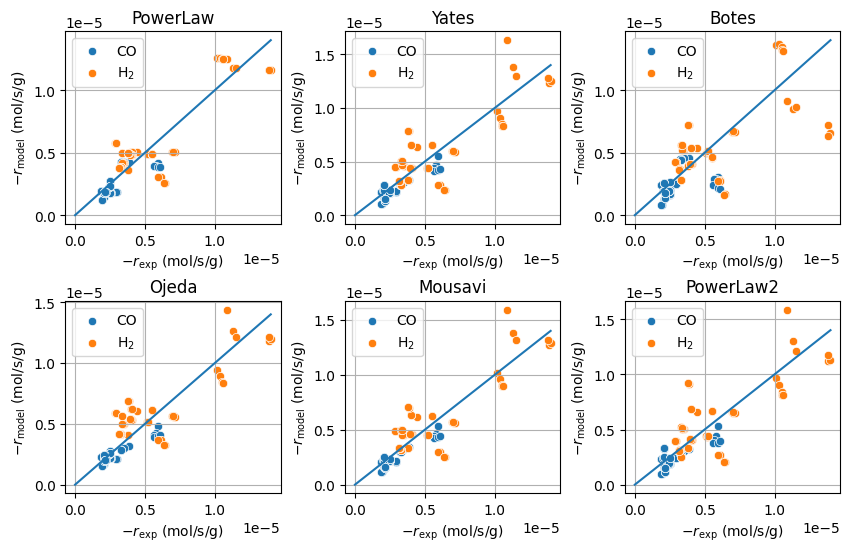

In [46]:
plot_parity(f'{fig_path}fit_parity_rate.pdf', 'rate', kinetic_data.loc[loc_training])

In [47]:
def solve_bootstrap(model_name, rate_fcn, p0, bnds, bootstrap_sample, bootstrap_results, i, run):
    print(f'Bootstrap iteration {i} for {model_name}')
    clear_output(wait=True)
    max_fev = 200
    sol = fit_function(bootstrap_sample, rate_fcn, p0, bnds, model_name, max_fev)
    # MAE = calc_MAE(model_name)

    bootstrap_results['model'].append(model_name)
    bootstrap_results['iteration'].append(i)
    bootstrap_results['run'].append(run)
    # bootstrap_results['mean_absolute_error'].append(MAE)
    bootstrap_results['params'].append(sol.x)
    bootstrap_results['success'].append(sol.success)
    bootstrap_results['nfev'].append(sol.nfev)
    bootstrap_results['message'].append(sol.message)

    return bootstrap_results

In [48]:
# bootstrapping
def run_bootstrap(args):
    boot_iterations, run = args
    bootstrap_results = {'model': [], 'iteration': [], 'run': [],
                         # 'mean_absolute_error': [], 
                         'params': [],
                     'success': [], 'nfev': [], 'message': [],
                    }
    for i in range(boot_iterations):
        # generate a bootstrap sample of the same len as kinetic data from the trainning data
        sample_size = int(len(kinetic_data)/1)
        np.random.seed(None)
        bootstrap_sample = kinetic_data.loc[loc_training].sample(n = sample_size, replace = True)
    
        bootstrap_results = solve_bootstrap('PowerLaw', rate_HCs_PowerLaw, sol_PowerLaw.x, PowerLaw_bnds,
                                            bootstrap_sample, bootstrap_results, i, run)
    
        bootstrap_results = solve_bootstrap('Yates', rate_HCs_Yates, sol_Yates.x, Yates_bnds,
                                            bootstrap_sample, bootstrap_results, i, run)
    
        bootstrap_results = solve_bootstrap('Botes', rate_HCs_Botes, sol_Botes.x, Botes_bnds,
                                                bootstrap_sample, bootstrap_results, i, run)
        
        bootstrap_results = solve_bootstrap('Ojeda', rate_HCs_Ojeda, sol_Ojeda.x, Ojeda_bnds,
                                                bootstrap_sample, bootstrap_results, i, run)
        
        bootstrap_results = solve_bootstrap('PowerLaw2', rate_HCs_PowerLaw2, sol_PowerLaw2.x, PowerLaw2_bnds,
                                                bootstrap_sample, bootstrap_results, i, run)
        
        bootstrap_results = solve_bootstrap('Mousavi', rate_HCs_Mousavi, sol_Mousavi.x, Mousavi_bnds,
                                            bootstrap_sample, bootstrap_results, i, run)

    bootstrap_results = pd.DataFrame(bootstrap_results)

    return bootstrap_results

# if __name__ == '__main__':
# --- Parallel Execution ---

boot_iterations_per_run = 42

all_runs_input = [(boot_iterations_per_run, run) for run in range(24)]

# Get the number of CPU cores available for parallel processing
num_processes = multiprocessing.cpu_count()
if len(all_runs_input) < num_processes:
    num_processes = len(all_runs_input)
print(f"Using {num_processes} cores for parallel processing.")

# Create a Pool of worker processes
with multiprocessing.Pool(processes=num_processes) as pool:
    # pool.map() applies the run_single_bootstrap function to every item
    # in the all_runs_input list and waits for results.
    results = pool.map(run_bootstrap, all_runs_input)

bootstrap_results = pd.concat([result for result in results])

bootstrap_results.to_pickle('bootstrap_results.pkl')

In [49]:
bootstrap_results = pd.read_pickle('bootstrap_results.pkl')

def build_params_df(bootstrap_model_results, params_names):
    params = bootstrap_model_results.params
    params = np.stack(params.values)
    params = pd.DataFrame(params, columns = params_names)
    return params

PowerLaw_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'PowerLaw'],
                               ('A_HCs', 'E_HCs', 'a', 'b'))

Yates_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Yates'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

Botes_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Botes'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

Ojeda_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Ojeda'],
                               ('k_ads', 'H_ads', 'A_HCs_1', 'E_HCs_1', 'A_HCs_2', 'E_HCs_2'))

Mousavi_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Mousavi'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

PowerLaw2_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'PowerLaw2'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs', 'a', 'b', 'c'))

def build_median_IQR_df(params_df):
    median = params_df.median()
    Q1 = params_df.quantile(0.25)
    Q3 = params_df.quantile(0.75)
    return pd.DataFrame((Q1, median, Q3), index = ['1st quartile', 'median', '3rd quartile'])

PowerLaw_median_IQR = build_median_IQR_df(PowerLaw_params)
Yates_median_IQR = build_median_IQR_df(Yates_params)
Botes_median_IQR = build_median_IQR_df(Botes_params)
Ojeda_median_IQR = build_median_IQR_df(Ojeda_params)
Mousavi_median_IQR = build_median_IQR_df(Mousavi_params)
PowerLaw2_median_IQR = build_median_IQR_df(PowerLaw2_params)

update_pred_rate(rate_HCs_PowerLaw, 'PowerLaw', PowerLaw_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_Yates, 'Yates', Yates_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_Botes, 'Botes', Botes_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_Ojeda, 'Ojeda', Ojeda_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_Mousavi, 'Mousavi', Mousavi_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_PowerLaw2, 'PowerLaw2', PowerLaw2_median_IQR.loc['median'].values)

# test data must be updated from kinetic_data because kinetic data is updated during each fit
kinetic_data.loc[loc_validation] = kinetic_data.loc[loc_validation]

In [50]:
# the PBR script expects mass as kg, so must convert from g to kg

PowerLaw_param_dict = dict(PowerLaw_median_IQR.loc['median'])
PowerLaw_param_dict['A_HCs'] = PowerLaw_param_dict['A_HCs']*1000

Yates_param_dict = dict(Yates_median_IQR.loc['median'])
Yates_param_dict['A_HCs'] = Yates_param_dict['A_HCs']*1000

Botes_param_dict = dict(Botes_median_IQR.loc['median'])
Botes_param_dict['A_HCs'] = Botes_param_dict['A_HCs']*1000

Ojeda_param_dict = dict(Ojeda_median_IQR.loc['median'])
Ojeda_param_dict['A_HCs_1'] = Ojeda_param_dict['A_HCs_1']*1000
Ojeda_param_dict['A_HCs_2'] = Ojeda_param_dict['A_HCs_2']*1000

Mousavi_param_dict = dict(Mousavi_median_IQR.loc['median'])
Mousavi_param_dict['A_HCs'] = Mousavi_param_dict['A_HCs']*1000

PowerLaw2_param_dict = dict(PowerLaw2_median_IQR.loc['median'])
PowerLaw2_param_dict['A_HCs'] = PowerLaw2_param_dict['A_HCs']*1000

params_dict = {
    'PowerLaw'  : PowerLaw_param_dict,
    'Yates'     : Yates_param_dict,
    'Botes'     : Botes_param_dict,
    'Ojeda'     : Ojeda_param_dict,
    'Mousavi'   : Mousavi_param_dict,
    'PowerLaw2' : PowerLaw2_param_dict,
              }

In [51]:
from solve_ODEs import solve_ODEs

In [52]:
model_names = ['PowerLaw', 'Yates', 'Botes', 'Ojeda', 'Mousavi', 'PowerLaw2']

for model in model_names:
    kinetic_data = solve_ODEs(kinetic_data, model, params_dict[model])

kinetic_data.to_pickle('kinetic_data.pkl')

In [54]:
kinetic_data = pd.read_pickle('kinetic_data.pkl')

In [55]:
for model in model_names:
    kinetic_data[f'residuals_boot_{model}'] =  kinetic_data.F_H2_s_mol_s - kinetic_data[f'F_H2_out_model_{model}']
    kinetic_data[f'residuals_boot_{model}'] += kinetic_data.F_CO_s_mol_s - kinetic_data[f'F_CO_out_model_{model}']

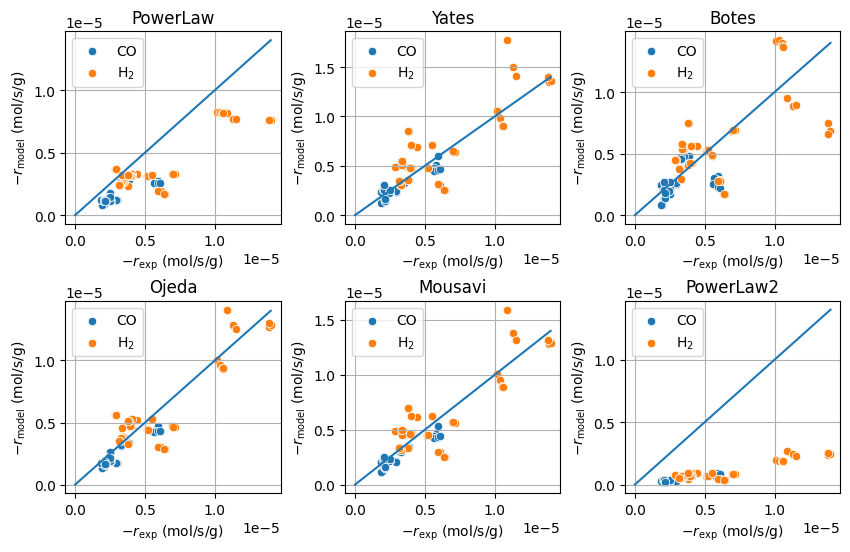

In [56]:
plot_parity(f'{fig_path}fit_parity_rate.pdf', 'rate', kinetic_data.loc[loc_training])

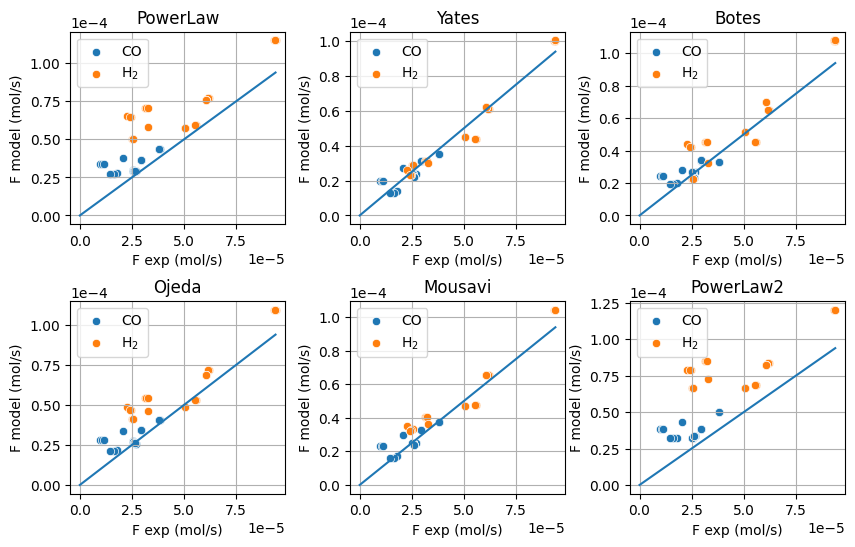

In [57]:
plot_parity(f'{fig_path}parity_F_validation.pdf', 'F', kinetic_data.loc[loc_validation])

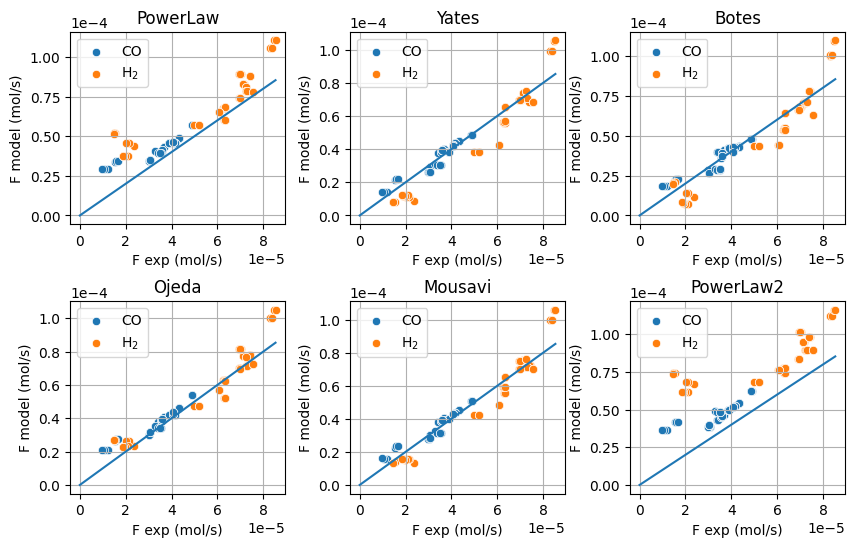

In [58]:
plot_parity(f'{fig_path}parity_F_train.pdf', 'F', kinetic_data.loc[loc_training])

In [59]:
stats_bootstrap = {'model': model_names, 
                   # 'AICc test': [], 
                   'AICc train': [], 'AICc val': [],
                   # 'MAE test': [],
                   'MAE train': [], 'MAE val': [],
                  }

In [60]:
from sklearn.metrics import mean_absolute_error

In [61]:
for model in model_names:
    train_res = kinetic_data.loc[loc_training, f'residuals_boot_{model}']
    val_res =  kinetic_data.loc[loc_validation, f'residuals_boot_{model}']

    train_dataset = kinetic_data.loc[loc_training]
    val_dataset = kinetic_data.loc[loc_validation]

    y_true_train = np.append(train_dataset.F_H2_s_mol_s.values, train_dataset.F_CO_s_mol_s.values)
    y_pred_train = np.append(train_dataset[f'F_H2_out_model_{model}'], train_dataset[f'F_CO_out_model_{model}'])
    
    y_true_val = np.append(val_dataset.F_H2_s_mol_s.values, val_dataset.F_CO_s_mol_s.values)
    y_pred_val = np.append(val_dataset[f'F_H2_out_model_{model}'], val_dataset[f'F_CO_out_model_{model}'])
    
    stats_bootstrap['AICc train'].append(AICc(train_res, train_res, params_dict[model]))
    stats_bootstrap['AICc val'].append(AICc(val_res, val_res, params_dict[model]))

    stats_bootstrap['MAE train'].append(mean_absolute_error(y_true_train, y_pred_train))
    stats_bootstrap['MAE val'].append(mean_absolute_error(y_true_val, y_pred_val))

In [62]:
stats_bootstrap = pd.DataFrame(stats_bootstrap).sort_values(by = 'AICc val')

In [63]:
stats_bootstrap

,model,AICc train,AICc val,MAE train,MAE val
1,Yates,-1192.126140,-526.260496,0.000005,0.000004
4,Mousavi,-1209.320018,-515.729307,0.000004,0.000005
2,Botes,-1175.612848,-496.374797,0.000005,0.000007
3,Ojeda,-1203.508961,-489.218747,0.000005,0.000009
0,PowerLaw,-1170.997779,-481.952369,0.000010,0.000014
5,PowerLaw2,-1130.325339,-461.806802,0.000019,0.000022


In [64]:
stats_bootstrap.sort_values(by = 'AICc train')

,model,AICc train,AICc val,MAE train,MAE val
4,Mousavi,-1209.320018,-515.729307,0.000004,0.000005
3,Ojeda,-1203.508961,-489.218747,0.000005,0.000009
1,Yates,-1192.126140,-526.260496,0.000005,0.000004
2,Botes,-1175.612848,-496.374797,0.000005,0.000007
0,PowerLaw,-1170.997779,-481.952369,0.000010,0.000014
5,PowerLaw2,-1130.325339,-461.806802,0.000019,0.000022


In [65]:
stats_bootstrap.sort_values(by = 'MAE train')

,model,AICc train,AICc val,MAE train,MAE val
4,Mousavi,-1209.320018,-515.729307,0.000004,0.000005
1,Yates,-1192.126140,-526.260496,0.000005,0.000004
3,Ojeda,-1203.508961,-489.218747,0.000005,0.000009
2,Botes,-1175.612848,-496.374797,0.000005,0.000007
0,PowerLaw,-1170.997779,-481.952369,0.000010,0.000014
5,PowerLaw2,-1130.325339,-461.806802,0.000019,0.000022


In [66]:
stats_bootstrap.sort_values(by = 'MAE val')

,model,AICc train,AICc val,MAE train,MAE val
1,Yates,-1192.126140,-526.260496,0.000005,0.000004
4,Mousavi,-1209.320018,-515.729307,0.000004,0.000005
2,Botes,-1175.612848,-496.374797,0.000005,0.000007
3,Ojeda,-1203.508961,-489.218747,0.000005,0.000009
0,PowerLaw,-1170.997779,-481.952369,0.000010,0.000014
5,PowerLaw2,-1130.325339,-461.806802,0.000019,0.000022


In [67]:
print(stats_bootstrap.to_latex(index=False, 
                                  formatters = {
                                                'AICc train': "{:.1f}",
                                                'AICc val': "{:.1f}",
                                                'MAE train': "{:.1E}",
                                                'MAE val': "{:.1E}",
                                               }
                                 ))

\begin{tabular}{lrrrr}
\toprule
model & AICc train & AICc val & MAE train & MAE val \\
\midrule
Yates & -1192.1 & -526.3 & 4.9E-06 & 3.8E-06 \\
Mousavi & -1209.3 & -515.7 & 4.4E-06 & 5.1E-06 \\
Botes & -1175.6 & -496.4 & 5.3E-06 & 6.7E-06 \\
Ojeda & -1203.5 & -489.2 & 4.9E-06 & 8.6E-06 \\
PowerLaw & -1171.0 & -482.0 & 1.0E-05 & 1.4E-05 \\
PowerLaw2 & -1130.3 & -461.8 & 1.9E-05 & 2.2E-05 \\
\bottomrule
\end{tabular}



In [68]:
Mousavi_median_IQR.loc['median'].values

array([5.43455294e-06, 4.66547818e-04, 2.19397703e+01, 1.59680171e+05])

In [69]:
print(Mousavi_median_IQR.to_latex(index=True, 
                                  formatters = {
                                                'k_ads': lambda x: f"\\num{{{x:.2E}}}",
                                                'H_ads': lambda x: f"\\num{{{x:.2E}}}",
                                                'A_HCs': lambda x: f"\\num{{{x:.2E}}}",
                                                'E_HCs': lambda x: f"\\num{{{x:.0f}}}"
                                            }
                                 ))

\begin{tabular}{lrrrr}
\toprule
 & k_ads & H_ads & A_HCs & E_HCs \\
\midrule
1st quartile & \num{4.55E-06} & \num{1.53E-06} & \num{1.29E+01} & \num{157411} \\
median & \num{5.43E-06} & \num{4.67E-04} & \num{2.19E+01} & \num{159680} \\
3rd quartile & \num{6.54E-06} & \num{2.54E-03} & \num{3.68E+01} & \num{161681} \\
\bottomrule
\end{tabular}



In [70]:
Yates_median_IQR.loc['median']

k_ads         0.000007
H_ads         0.000430
A_HCs        11.153429
E_HCs    169821.118510
Name: median, dtype: float64

In [71]:
print(Yates_median_IQR.to_latex(index=True, 
                                  formatters = {
                                                'k_ads': lambda x: f"\\num{{{x:.2E}}}",
                                                'H_ads': lambda x: f"\\num{{{x:.2E}}}",
                                                'A_HCs': lambda x: f"\\num{{{x:.2E}}}",
                                                'E_HCs': lambda x: f"\\num{{{x:.0f}}}"
                                            }
                                 ))

\begin{tabular}{lrrrr}
\toprule
 & k_ads & H_ads & A_HCs & E_HCs \\
\midrule
1st quartile & \num{5.12E-06} & \num{1.60E-08} & \num{5.75E+00} & \num{166693} \\
median & \num{6.58E-06} & \num{4.30E-04} & \num{1.12E+01} & \num{169821} \\
3rd quartile & \num{8.83E-06} & \num{3.05E-03} & \num{2.17E+01} & \num{172432} \\
\bottomrule
\end{tabular}

